In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()





In [3]:
x=pd.read_csv(r"C:\Users\shivam parihari\Downloads\iris\iris.data",header=None)

In [4]:
x.columns=['sl','sw','pl','pw','class']
x['class']=le.fit_transform(x['class'])

In [5]:
ip=x.drop(columns='class')
ip


,sl,sw,pl,pw
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
op=x['class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(ip, op, test_size=0.33)

In [8]:
base_learners=[
    ('dt',DecisionTreeClassifier(random_state=42)),
    ('svc',SVC(probability=True,kernel='rbf',random_state=42)),
    ('lr',LogisticRegression(max_iter=1000))
    
]

In [9]:
meta_learner=LogisticRegression(max_iter=1000)

In [10]:
stacking_clf=StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

In [11]:
stacking_clf.fit(X_train,y_train)

StackingClassifier(cv=5,
                   estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [12]:
pred=stacking_clf.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
accuracy_score(y_test,pred)

0.98

#### Bagging (random forest classifier) : overfitted to generalised

In [15]:
from sklearn.ensemble import RandomForestClassifier


In [16]:
rf_model= RandomForestClassifier()

In [17]:
rf_model.fit(X_train,y_train)

RandomForestClassifier()

In [18]:
pred=rf_model.predict(X_test)

In [19]:
accuracy_score(pred,y_test)

1.0

#### Boosting(XG boost) converts underfitted data to generalised 

In [20]:
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier

In [21]:
ada_model=AdaBoostClassifier(
n_estimators=100,random_state=42)
ada_model.fit(X_train,y_train)
pred1=ada_model.predict(X_test)
accuracy_score(pred,y_test)

1.0

In [22]:
grad=GradientBoostingClassifier()
grad.fit(X_train,y_train)
pred2=grad.predict(X_test)
accuracy_score(pred2,y_test)

1.0

In [23]:
from xgboost import XGBClassifier

In [24]:
xgb=XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,eval_metric='mlogloss',random_state=42,use_label_encoder=False)

In [25]:
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
pred4=xgb.predict(X_test)

In [27]:
accuracy_score(pred4,y_test)

1.0

#### Unsupervised ML

#### K-Means clusstering

In [28]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [29]:
X,y_true=make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [30]:
X

array([[-6.1900632 , -7.30201545],
       [ 3.02174685,  1.94059276],
       [ 5.9537606 ,  1.48819071],
       [-2.74446251,  8.13617716],
       [ 5.36060719,  1.72832446],
       [ 5.13808033,  1.45951939],
       [-5.34357647, -6.93774553],
       [ 4.80215293,  1.94302682],
       [ 3.99930658,  1.88774199],
       [-7.25451834, -6.86445496],
       [ 4.25193511,  1.32424088],
       [-1.81404028,  8.52187674],
       [-1.2293776 ,  7.84303345],
       [-2.16666332,  9.69562551],
       [ 4.81374375,  3.21841016],
       [ 5.27493353,  0.91792599],
       [-2.5524037 ,  9.61640587],
       [-7.5532604 , -6.65066375],
       [-6.8302568 , -6.24082137],
       [-3.17299861,  8.29656215],
       [ 3.80073829,  2.31095123],
       [-2.38387947,  7.83848405],
       [ 4.98581301,  2.15991978],
       [-5.94031277, -6.91955975],
       [-7.14748736, -6.7636556 ],
       [ 4.87655012,  1.720579  ],
       [ 4.48689251,  2.87556548],
       [-6.4081471 , -6.62483506],
       [-6.71939703,

In [31]:
y=pd.DataFrame(X,columns=['feature1','feature2'])
y

,feature1,feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [32]:
sc=StandardScaler()
y1 = pd.DataFrame(sc.fit_transform(y), columns=['feature1', 'feature2'])


In [33]:
inertia=[] 
# for elbow method ye krna hai
K_range=range(1,11)
# 1 se 11 clisters 

In [34]:
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(y1)
    inertia.append(kmeans.inertia_)
    

In [35]:
inertia

[1000.0000000000001,
 297.8954141051722,
 11.575484723104982,
 9.752067977356843,
 8.25717527244628,
 6.917577320416798,
 6.334755391595288,
 5.704177177901429,
 5.060234133532076,
 4.762361898130397]

Text(0.5, 1.0, 'elbow curve')

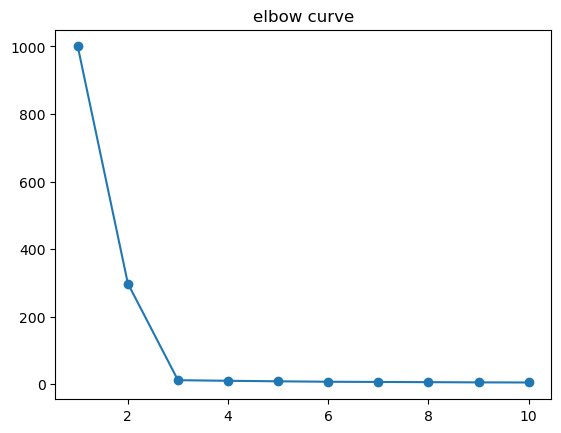

In [36]:
plt.plot(K_range,inertia,marker='o')
plt.title('elbow curve')

In [37]:
kfinal=KMeans(n_clusters=3,random_state=42)

In [38]:
cluster_labels= kfinal.fit_predict(y1)

In [39]:
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [40]:
y1['cluster']=cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

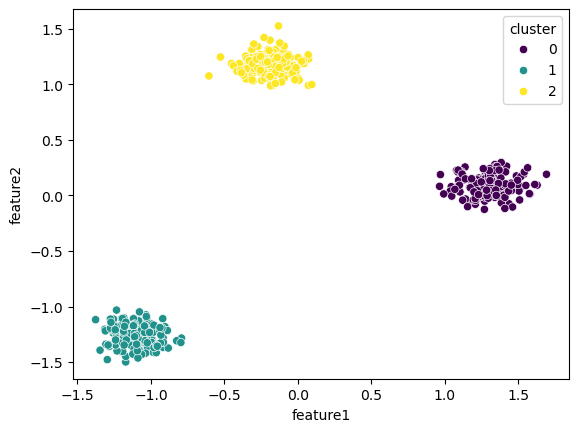

In [41]:
sns.scatterplot(x=y1['feature1'],y=y1['feature2'],hue=y1['cluster'],palette='viridis')

#### disadvantages:
<ul><li>we have to initialize k value and sometimes it isnt clear through elbow curve also.
<li>outliers will move the center point.
<li>non circular data dikkat deti hai

### Density based algorithm:DB scan algorithm
<ul><li>non parametric algorithm
<li>epsilon distance


In [43]:
from sklearn.datasets import make_moons


In [44]:
X,y_true=make_moons(n_samples=500,noise=0.05,random_state=42)

In [45]:
from sklearn.cluster import KMeans,DBSCAN

In [46]:
df=pd.DataFrame(X,columns=['feature1','feature2'])

In [48]:
sc=StandardScaler()
y2 = pd.DataFrame(sc.fit_transform(df), columns=['feature1', 'feature2'])


In [49]:
kmeans=KMeans(n_clusters=2,random_state=42)
labels=kmeans.fit_predict(y2)

In [50]:
df['kmeans_cluster']=labels

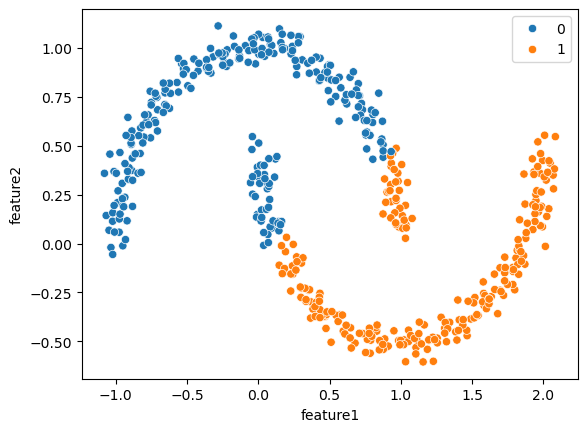

In [52]:
sns.scatterplot(x=df['feature1'],y=df['feature2'],hue=labels,palette='tab10')
plt.show()

In [53]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
labels=dbscan.fit_predict(y2)

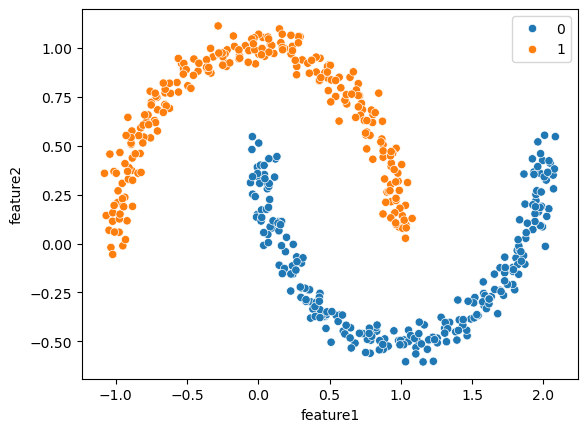

In [54]:
df['dbscan_clusters']=labels
sns.scatterplot(x=df['feature1'],y=df['feature2'],hue=labels,palette='tab10')
plt.show()

#### dimensionality reduction
<ul><li><b>curse of dimension</b>:<br>
        difficult to find patterns due to increase in dimensions or features
<li>knn,dbscan,kmeans fail
<li>storage and model training time increases   
<li>alwys some amt of info will be lost.

In [55]:
from sklearn.decomposition import PCA

In [56]:
X,y_true=make_blobs(n_samples=500,centers=3,cluster_std=1.5,random_state=42,n_features=5)

In [57]:
X

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]])

In [58]:
X1=sc.fit_transform(X)

In [59]:
model=PCA(n_components=2)
x_pca=model.fit_transform(X1)

In [60]:
x_pca

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [61]:
df_pca=pd.DataFrame(x_pca,columns=['pc1','pc2'])

In [70]:
df_pca['label']=y_true

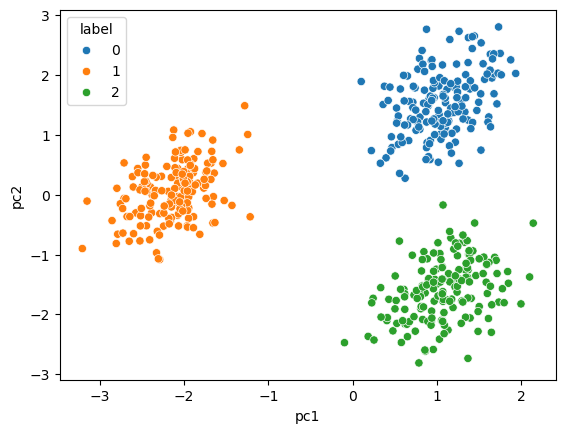

In [71]:
sns.scatterplot(x='pc1',y='pc2',hue='label',palette='tab10',data=df_pca)
plt.show()